In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [61]:
df = pd.read_csv('Final_Project_export/data2.txt', header=None, names=['x', 'y'])
x = df['x'].values
y = df['y'].values

In [62]:
# *p 表示接受任意多个参数，这样我们可以用同一个函数处理不同的 degree
def poly_model(x, *p):
    # np.polyval 计算多项式的值
    return np.polyval(p, x)

degrees = range(1, 10)
mse_list = []
models = {} # 存一下模型系数，方便后面画图用

# 循环 1 到 9 次，计算每个degree的模型
for deg in degrees:
    p0 = [1.0] * (deg + 1) # 暂时设p0全为1.0
    popt, pcov = curve_fit(poly_model, x, y, p0=p0)
    models[deg] = popt
    # 算一下MSE
    y_pred = poly_model(x, *popt)
    mse = np.mean((y - y_pred)**2)
    mse_list.append(mse)

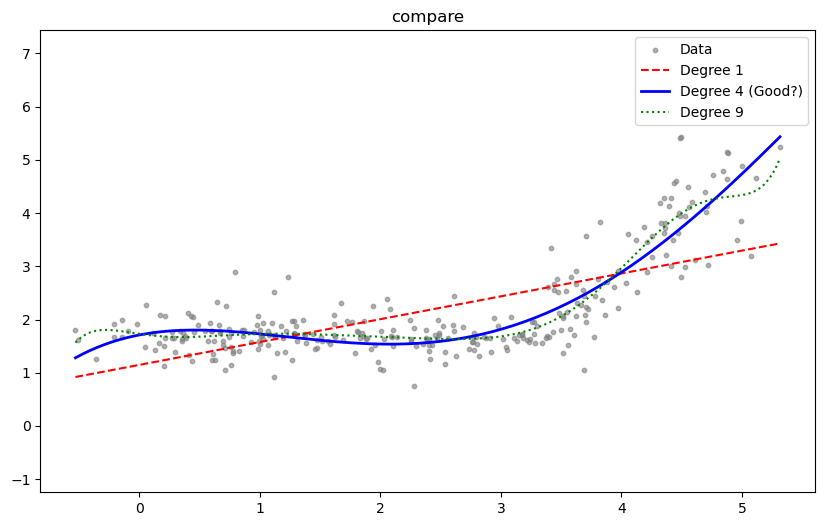

In [ ]:
x_line = np.linspace(min(x), max(x), 200)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, color='gray', alpha=0.6, label='Data')

# 画出 Degree 1, 4, 9 的曲线
# 使用 *models[deg] 把存好的系数传进去
plt.plot(x_line, poly_model(x_line, *models[1]), 'r--', label='Degree 1')
plt.plot(x_line, poly_model(x_line, *models[4]), 'b-', linewidth=2, label='Degree 4 (Good?)')
plt.plot(x_line, poly_model(x_line, *models[9]), 'g:', label='Degree 9 ')

plt.title('compare')
plt.legend()
plt.ylim(min(y)-2, max(y)+2) 
plt.show()

Degree      MSE       
-------------------------
1           0.46275
2           0.22693
3           0.19236
4           0.18817
5           0.17174
6           0.16994
7           0.16780
8           0.16621
9           0.16485


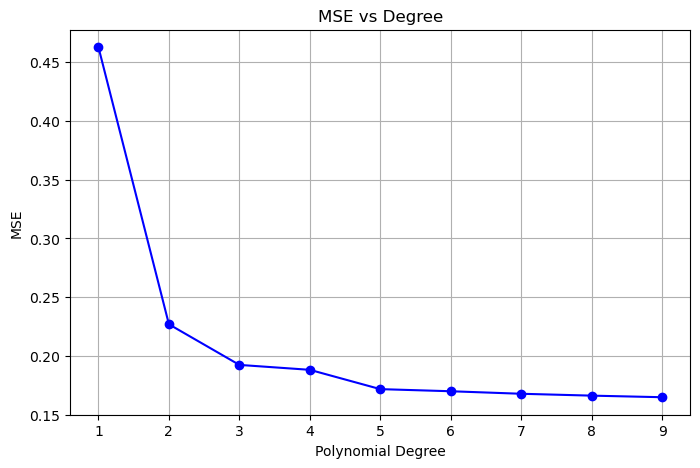

In [ ]:
#验证
print(f"{'Degree':<10}  {'MSE':<10}")
print("-"*25)
for i in range(len(degrees)):
    print(f"{degrees[i]:<10}  {mse_list[i]:.5f}")

plt.figure(figsize=(8, 5))
plt.plot(degrees, mse_list, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('MSE vs Degree')
plt.grid(True)
plt.show()

Degree      Train MSE     Test MSE    
1           0.45657      0.49310
2           0.21284      0.28482
3           0.17267      0.27589
4           0.17066      0.26374
5           0.15544      0.24015
6           0.15283      0.24217
7           0.14860      0.24851
8           0.14517      0.25486
9           0.14444      0.25154


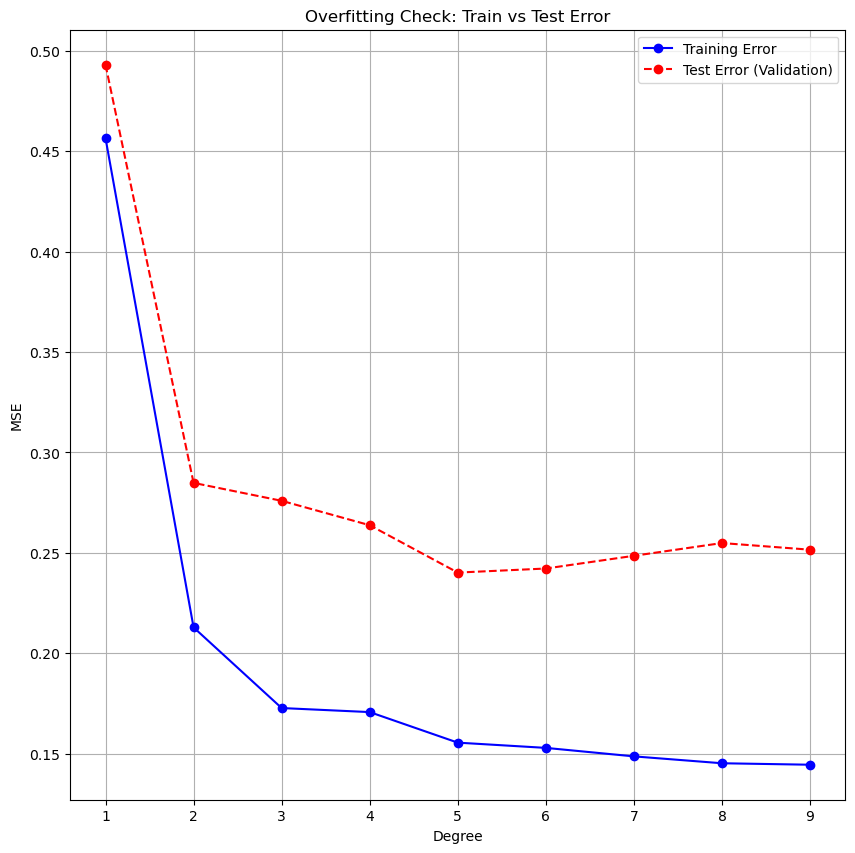

In [65]:
#检测过拟合
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

train_error = []
test_error = []

print(f"{'Degree':<10}  {'Train MSE':<12}  {'Test MSE':<12}")
for deg in degrees:
    p0 = [1.0] * (deg + 1)
    popt, _ = curve_fit(poly_model, x_train, y_train, p0=p0)
    
    # Training Error
    y_train_pre = poly_model(x_train, *popt)
    # 使用 sklearn 的 mean_squared_error 计算误差
    train_mse = mean_squared_error(y_train, y_train_pre)
    
    # Test Error
    y_test_pre = poly_model(x_test, *popt)
    test_mse = mean_squared_error(y_test, y_test_pre)
    
    train_error.append(train_mse)
    test_error.append(test_mse)
    
    print(f"{deg:<10}  {train_mse:.5f}      {test_mse:.5f}")

plt.figure(figsize=(10, 10))
plt.plot(degrees, train_error, 'b-o', label='Training Error')
plt.plot(degrees, test_error, 'r--o', label='Test Error (Validation)')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.title('Overfitting Check: Train vs Test Error')
plt.legend()
plt.grid(True)
plt.show()

My Breakpoint: 3.2060
My Model Error: 0.17281


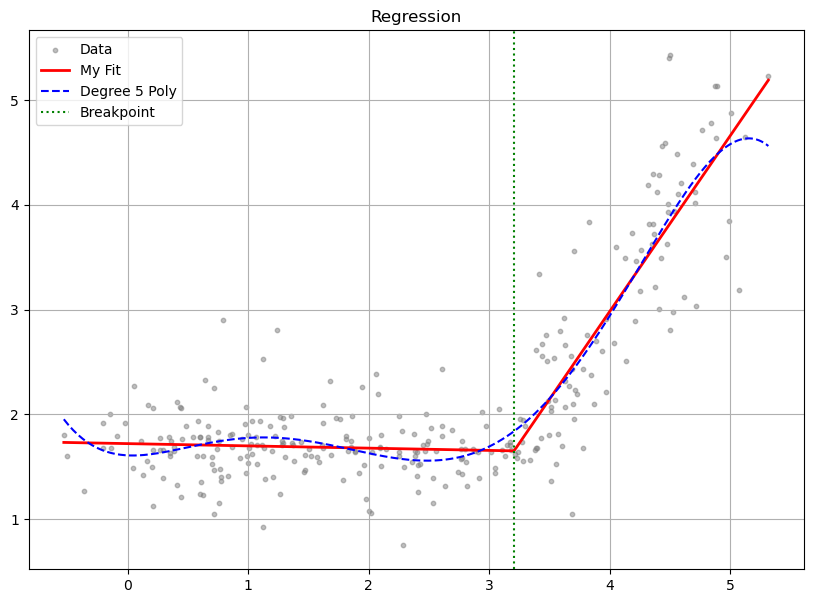

In [66]:
#this is for task 4

#定义两段分段函数
def pieceFuc(x, x0, k1, b1, k2):
    # 当 x < x0 时, 用第一段
    # 当 x >= x0 时, 用二段
    return np.piecewise(x, [x < x0], [
        lambda x: k1 * x + b1, 
        lambda x: k1 * x0 + b1 + k2 * (x - x0)
    ])

# 2. 拟合模型
#随便写参数
guess = [np.mean(x), 1, 0, 1]

# 找参数
p, cov = curve_fit(pieceFuc, x, y, p0=guess)

breakpoint = p[0]
print(f"My Breakpoint: {breakpoint:.4f}")

# 3. 计算误差 (MSE)
y_pred = pieceFuc(x, *p)
error = mean_squared_error(y, y_pred)
print(f"My Model Error: {error:.5f}")

plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=10, color='gray', alpha=0.5, label='Data')

xx = np.linspace(min(x), max(x), 300)
plt.plot(xx, pieceFuc(xx, *p), 'r-', linewidth=2, label='My Fit')

if 'models' in locals() and 5 in models:
    plt.plot(xx, poly_model(xx, *models[5]), 'b--', label='Degree 5 Poly')

plt.axvline(x=breakpoint, color='green', linestyle=':', label='Breakpoint')
plt.legend()
plt.title('Regression')
plt.grid(True)
plt.show()